# Pandas: Groupby

Often we don't want a single summary for the whole dataset — we want **one value per group**: the average temperature in each *month*, the strongest earthquake in each *country*, the total rainfall in each *year*. `groupby` is the tool for exactly this, and it's one of the most useful things pandas does.

The pattern it follows is called **split–apply–combine**: split the rows into groups, apply a calculation to each group, then combine the results back together. We'll build that intuition on two datasets — first grouping earthquakes **by country**, then grouping a weather station's daily record **by time** to build climatologies and anomalies. Along the way we'll meet `groupby`'s close relatives **`resample`** (grouping by time interval) and **`rolling`** (moving-window calculations).

These notes draw on the [pandas groupby documentation](http://pandas.pydata.org/pandas-docs/stable/groupby.html); the split-apply-combine framing comes from a [paper by Hadley Wickham](https://www.jstatsoft.org/article/view/v040i01).

:::{admonition} Working through this notebook
:class: tip
This page is a Jupyter notebook. **Download it** using the ⬇ button in the top-right (or copy-paste the cells into a fresh notebook), open it in your environment (JupyterLab on LEAP or Colab), and step through the cells. When you reach a **Try it** admonition, experiment in your own cells before moving on.
:::

:::{admonition} In-class assignment — 10 points
:class: note
The **"Try it"** exercises in this notebook are part of your in-class assignment for this section. Complete them in your own copy of the notebook, push it to your week folder, and post the notebook link on the matching **Courseworks** assignment. (One 10-point assignment covers all the lecture notebooks in this section.)
:::

In [1]:
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12,7)
%matplotlib inline
import pandas as pd

First we read the earthquake data from the previous assignment. Two extra steps set up the rest of the lesson: we derive a `country` column from the free-text `place` field, and we split the catalog by magnitude into the larger events (`df`, magnitude > 4) and the smaller ones (`df_small`, magnitude < 4), so we can compare the two groups later.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/earth-DS-ML/summer_2026/refs/heads/main/lectures_DS/data/usgs_earthquakes_2025.csv', parse_dates=['time'], index_col='id')
df['country'] = df.place.str.split(', ').str[-1]
df_small = df[df.mag<4]
df = df[df.mag>4]
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,country
id,,,,,,,,,,,,,,,,,,,,,
us6000qkt1,2025-06-17 12:00:22.773000+00:00,-23.1645,-175.3549,10.000,4.9,mb,22.0,166.0,6.481,0.49,...,"206 km SSW of ‘Ohonua, Tonga",earthquake,15.85,1.938,0.093,36.0,reviewed,us,us,Tonga
us6000qksf,2025-06-17 09:16:30.483000+00:00,-23.1181,-174.9129,10.000,4.8,mb,16.0,111.0,6.151,0.48,...,"196 km S of ‘Ohonua, Tonga",earthquake,14.94,1.939,0.148,14.0,reviewed,us,us,Tonga
us6000qks2,2025-06-17 08:36:22.986000+00:00,8.2769,126.8035,34.840,5.3,mww,100.0,67.0,1.706,1.23,...,"42 km ENE of Barcelona, Philippines",earthquake,7.91,3.994,0.062,25.0,reviewed,us,us,Philippines
us6000qkrz,2025-06-17 08:13:19.239000+00:00,50.6542,156.7597,91.831,4.7,mb,55.0,152.0,2.526,0.64,...,"44 km E of Severo-Kuril’sk, Russia",earthquake,10.38,7.726,0.032,287.0,reviewed,us,us,Russia
us6000qks0,2025-06-17 08:12:55.629000+00:00,-32.8812,-13.2948,10.000,5.0,mb,44.0,59.0,4.254,0.91,...,southern Mid-Atlantic Ridge,earthquake,10.55,1.837,0.076,55.0,reviewed,us,us,southern Mid-Atlantic Ridge


Before grouping, let's get oriented — how many large events are in `df`, and what does the distribution of magnitudes look like?

In [3]:
len(df)

5923

<Axes: ylabel='Frequency'>

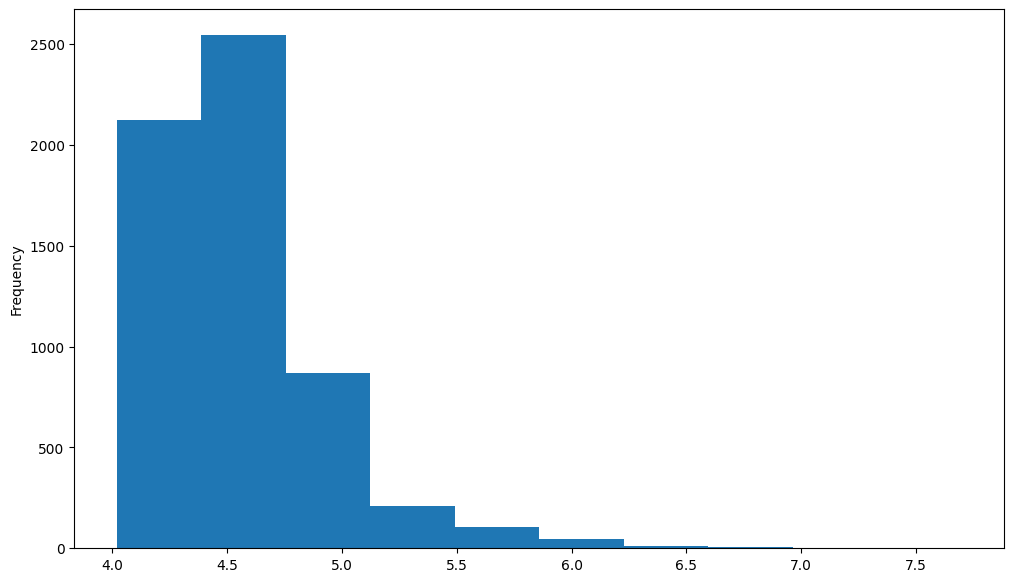

In [4]:
df.mag.plot.hist()

## An Example

What if we wanted to know which **country** had the most earthquakes? `groupby` does this cleanly — it groups all rows that share a value, then we can apply an aggregation (here, `count`) to summarize each group:

<Axes: xlabel='country'>

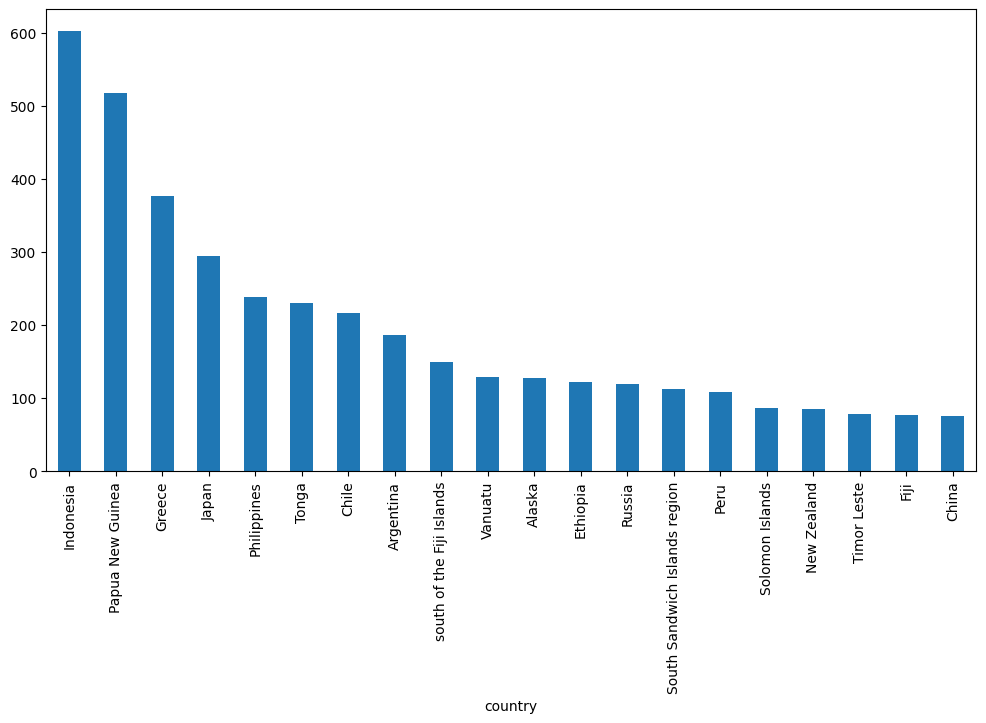

In [5]:
df.groupby('country').mag.count().nlargest(20).plot(kind='bar', figsize=(12,6))

And the same count for the *smaller* events (`df_small`, magnitude below 4) — notice how the ranking of countries shifts:

<Axes: xlabel='country'>

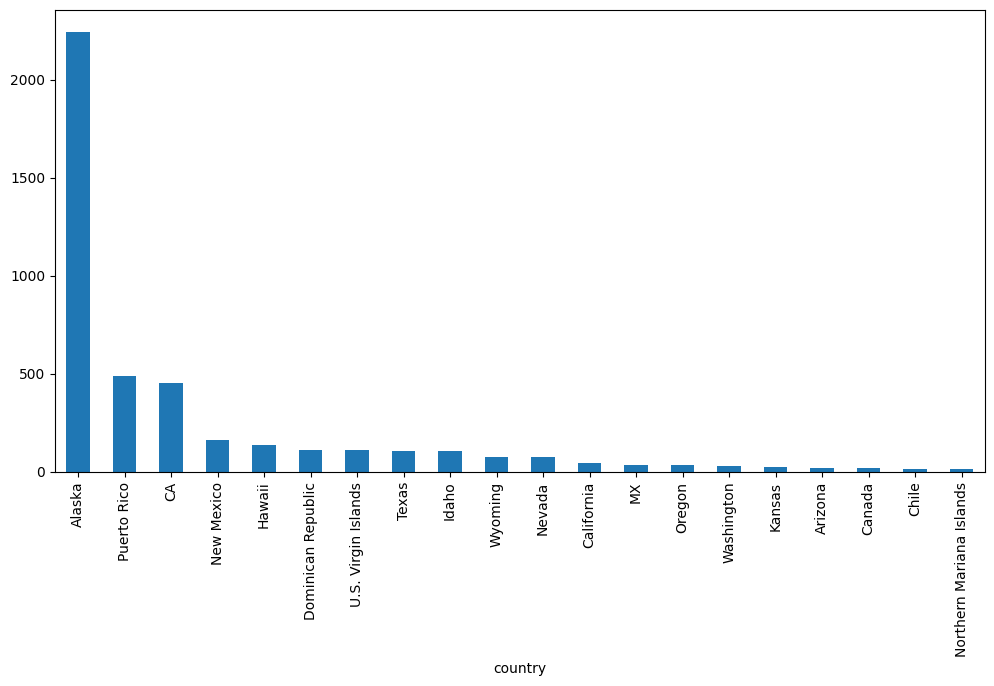

In [6]:
df_small.groupby('country').mag.count().nlargest(20).plot(kind='bar', figsize=(12,6))

## What Happened?

Let's break down what `groupby` actually does. The `.groupby(...)` call doesn't immediately compute anything — it returns a `GroupBy` object that holds the grouping logic. Computation happens when you call an aggregation method on it (`.count()`, `.mean()`, `.aggregate(...)`, etc.). This pattern is sometimes called **split-apply-combine**:

1. **Split** the data into groups based on a column or function.
2. **Apply** a function (aggregate, transform, or filter) to each group independently.
3. **Combine** the results back into a single DataFrame or Series.

We can group by any Series — here, the `country` column itself:

In [7]:
df.country

,country
id,
us6000qkt1,Tonga
us6000qksf,Tonga
us6000qks2,Philippines
us6000qkrz,Russia
us6000qks0,southern Mid-Atlantic Ridge
...,...
us6000pll8,Ethiopia
us6000pj3b,Libya
us6000pj2q,Tonga


In [8]:
df.groupby(df.country)

There is a shortcut for doing this with dataframes: you just pass the column name:

In [9]:
df.groupby('country')

### The `GroupBy` object

When we call `groupby`, we get back a `GroupBy` object:

In [10]:
gb = df.groupby('country')
gb

The length tells us how many groups were found:

In [11]:
len(gb)

194

All of the groups are available as a dictionary via the `.groups` attribute:

In [12]:
groups = gb.groups
len(groups)

194

In [13]:
groups.keys()

dict_keys(['2025 Drake Passage Earthquake', 'Afghanistan', 'Alaska', 'Algeria', 'Anguilla', 'Antigua and Barbuda', 'Arctic Ocean', 'Argentina', 'Armenia', 'Ascension Island region', 'Australia', 'Azerbaijan', 'Azores Islands region', 'Bahamas', 'Balleny Islands region', 'Banda Sea', 'Barbados', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Burma', 'Burma (Myanmar)', 'Burma (Myanmar) Earthquake', 'CA', 'Canada', 'Carlsberg Ridge', 'Cayman Islands', 'Chad', 'Chagos Archipelago region', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Democratic Republic of the Congo', 'Dominica', 'Dominican Republic', 'Drake Passage', 'Easter Island region', 'Ecuador', 'Ecuador region', 'El Salvador', 'Eritrea', 'Ethiopia', 'Federated States of Micronesia', 'Federated States of Micronesia region', 'Fiji', 'Fiji region', 'Georgia', 'Greece', 'Greenland Sea', 'Guadeloupe', 'Guam', 'Guatemala', 'Hawaii', 'Honduras', 'Iceland', 'Iceland region', 'Idaho', 'India', 'India region', 'Indian Ocean Triple

In [14]:
list(groups.keys())

['2025 Drake Passage Earthquake',
 'Afghanistan',
 'Alaska',
 'Algeria',
 'Anguilla',
 'Antigua and Barbuda',
 'Arctic Ocean',
 'Argentina',
 'Armenia',
 'Ascension Island region',
 'Australia',
 'Azerbaijan',
 'Azores Islands region',
 'Bahamas',
 'Balleny Islands region',
 'Banda Sea',
 'Barbados',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Brazil',
 'Burma',
 'Burma (Myanmar)',
 'Burma (Myanmar) Earthquake',
 'CA',
 'Canada',
 'Carlsberg Ridge',
 'Cayman Islands',
 'Chad',
 'Chagos Archipelago region',
 'Chile',
 'China',
 'Colombia',
 'Costa Rica',
 'Croatia',
 'Democratic Republic of the Congo',
 'Dominica',
 'Dominican Republic',
 'Drake Passage',
 'Easter Island region',
 'Ecuador',
 'Ecuador region',
 'El Salvador',
 'Eritrea',
 'Ethiopia',
 'Federated States of Micronesia',
 'Federated States of Micronesia region',
 'Fiji',
 'Fiji region',
 'Georgia',
 'Greece',
 'Greenland Sea',
 'Guadeloupe',
 'Guam',
 'Guatemala',
 'Hawaii',
 'Honduras',
 'Iceland',
 'Iceland region',
 'Idaho

### Selecting and iterating over groups

The `.groups` attribute is a regular Python dictionary — its keys are the group labels and its values are the row indices in each group. You can look up a single group by name:

In [15]:
groups['Afghanistan']

Index(['us6000qkkm', 'us6000qjhm', 'us6000qiif', 'us6000qhyi', 'us6000qh0s',
       'us7000q1by', 'us7000q0z5', 'us7000q0aw', 'us7000q05h', 'us7000pzz5',
       'us7000pyne', 'us7000pydu', 'us7000px78', 'us7000pwle', 'us7000pve9',
       'us7000pvcr', 'us7000pv82', 'us7000pv7x', 'us7000pv02', 'us6000q76g',
       'us6000q6fr', 'us7000pw58', 'us6000q6c3', 'us7000ppcq', 'us7000pni6',
       'us7000pni0', 'us7000pne1', 'us7000pn0e', 'us7000pmym', 'us7000plhv',
       'us7000plec', 'us6000pzkp', 'us6000pxul', 'us6000pwru', 'us6000pxge',
       'us6000pvsk', 'us7000pflg', 'us7000pfcc', 'us7000pfc9', 'us7000pefx',
       'us7000pd3k', 'us7000pchv', 'us7000pb68', 'us7000pb30', 'us6000pmd7',
       'us6000plpp', 'us6000pk88', 'us6000pk23', 'us6000pjtx', 'us6000pjpy',
       'us6000pjlp'],
      dtype='object', name='id')

You can also loop over the groups directly. Each step of the loop gives you the group's key and the sub-DataFrame of its rows:

In [16]:
for key, group in gb:
    display(group.head())
    print(f'The key is "{key}"')
    break

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,country
id,,,,,,,,,,,,,,,,,,,,,
us7000pwkn,2025-05-02 12:58:26.014000+00:00,-56.8094,-68.1019,10.0,7.4,mww,284.0,20.0,1.9,0.75,...,2025 Drake Passage Earthquake,earthquake,7.58,1.441,0.038,68.0,reviewed,us,us,2025 Drake Passage Earthquake


The key is "2025 Drake Passage Earthquake"


Finally, you can pull out one group as its own DataFrame with `get_group`:

In [17]:
gb.get_group('Chile').head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,country
id,,,,,,,,,,,,,,,,,,,,,
us6000qkjt,2025-06-16 08:19:27.151000+00:00,-22.5784,-67.9279,172.967,4.4,mb,41.0,49.0,0.438,0.61,...,"46 km NE of San Pedro de Atacama, Chile",earthquake,5.71,7.666,0.099,29.0,reviewed,us,us,Chile
us6000qkhr,2025-06-16 00:51:17.310000+00:00,-20.3278,-70.2485,41.960,4.4,mb,19.0,172.0,1.007,0.56,...,"13 km WSW of La Tirana, Chile",earthquake,4.55,10.951,0.309,3.0,reviewed,us,us,Chile
us6000qkfl,2025-06-15 13:30:08.837000+00:00,-22.3399,-68.6815,117.138,4.3,mb,28.0,46.0,0.750,1.13,...,"28 km ENE of Calama, Chile",earthquake,4.22,6.238,0.154,14.0,reviewed,us,us,Chile
us6000qjpw,2025-06-11 23:53:41.988000+00:00,-21.6724,-69.1225,98.543,4.1,mb,14.0,88.0,0.166,0.71,...,"89 km NNW of Calama, Chile",earthquake,7.11,10.366,0.234,5.0,reviewed,us,us,Chile
us6000qj2v,2025-06-09 00:59:17.293000+00:00,-32.2490,-71.0761,83.965,4.1,mb,28.0,131.0,0.222,0.19,...,"26 km NNE of La Ligua, Chile",earthquake,4.23,6.102,0.198,7.0,reviewed,us,us,Chile


:::{admonition} Try it
:class: tip
Take `df`. Use `groupby` to count the number of earthquakes per country and plot the top 10 as a bar chart (`df.groupby('country').mag.count().nlargest(10).plot.bar()`). Then use `gb.get_group('Chile')` to peek at the rows for a specific country.
:::

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,country
id,,,,,,,,,,,,,,,,,,,,,
us6000qkjt,2025-06-16 08:19:27.151000+00:00,-22.5784,-67.9279,172.967,4.4,mb,41.0,49.0,0.438,0.61,...,"46 km NE of San Pedro de Atacama, Chile",earthquake,5.71,7.666,0.099,29.0,reviewed,us,us,Chile
us6000qkhr,2025-06-16 00:51:17.310000+00:00,-20.3278,-70.2485,41.960,4.4,mb,19.0,172.0,1.007,0.56,...,"13 km WSW of La Tirana, Chile",earthquake,4.55,10.951,0.309,3.0,reviewed,us,us,Chile
us6000qkfl,2025-06-15 13:30:08.837000+00:00,-22.3399,-68.6815,117.138,4.3,mb,28.0,46.0,0.750,1.13,...,"28 km ENE of Calama, Chile",earthquake,4.22,6.238,0.154,14.0,reviewed,us,us,Chile
us6000qjpw,2025-06-11 23:53:41.988000+00:00,-21.6724,-69.1225,98.543,4.1,mb,14.0,88.0,0.166,0.71,...,"89 km NNW of Calama, Chile",earthquake,7.11,10.366,0.234,5.0,reviewed,us,us,Chile
us6000qj2v,2025-06-09 00:59:17.293000+00:00,-32.2490,-71.0761,83.965,4.1,mb,28.0,131.0,0.222,0.19,...,"26 km NNE of La Ligua, Chile",earthquake,4.23,6.102,0.198,7.0,reviewed,us,us,Chile


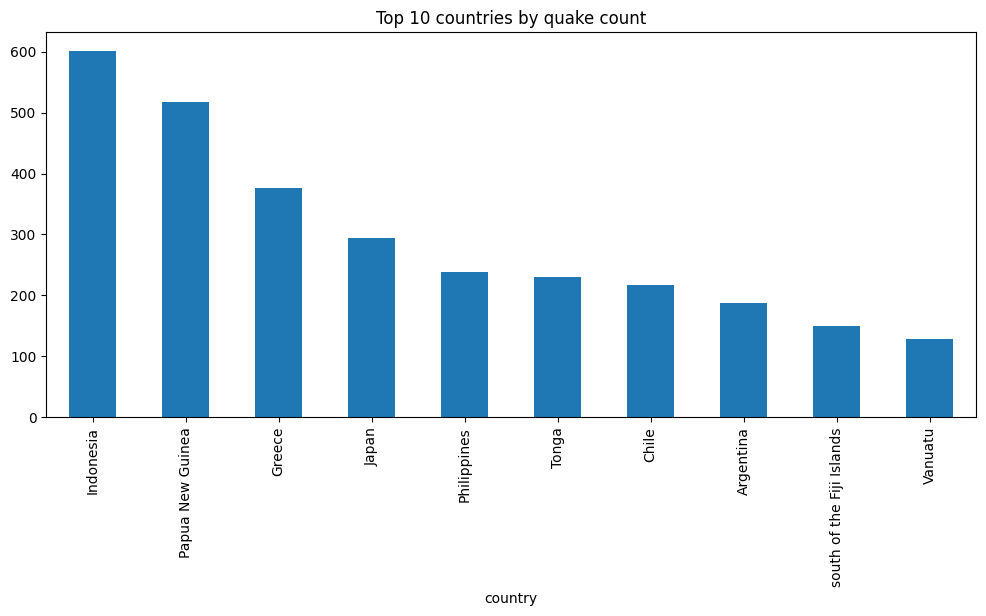

In [18]:
# Try it — my attempt
gb = df.groupby('country')
gb.mag.count().nlargest(10).plot.bar(figsize=(12, 5), title='Top 10 countries by quake count')
gb.get_group('Chile').head()

## Aggregation

Now that we know how to create a `GroupBy` object, let's learn how to do aggregation on it.

One way is to use the `.aggregate` method, which accepts another function as its argument. The result is automatically combined into a new dataframe with the group key as the index.

In [19]:
gb.aggregate('max').head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
country,,,,,,,,,,,,,,,,,,,,,
2025 Drake Passage Earthquake,2025-05-02 12:58:26.014000+00:00,-56.8094,-68.1019,10.000,7.4,mww,284.0,20.0,1.900,0.75,...,2025-06-06T12:21:50.736Z,2025 Drake Passage Earthquake,earthquake,7.58,1.441,0.038,68.0,reviewed,us,us
Afghanistan,2025-06-16 10:34:13.071000+00:00,37.4414,72.3551,230.241,5.7,mww,178.0,246.0,2.983,1.28,...,2025-06-16T11:33:01.040Z,"80 km SSE of Farkhār, Afghanistan",earthquake,11.79,13.714,0.235,154.0,reviewed,us,us
Alaska,2025-06-14 14:32:06.018000+00:00,67.8223,178.6746,205.536,6.2,mww,287.0,219.0,2.579,1.37,...,2025-06-17T12:05:18.488Z,"Rat Islands, Aleutian Islands, Alaska",earthquake,11.37,13.318,0.197,715.0,reviewed,us,us
Algeria,2025-03-18 09:50:26.946000+00:00,36.4349,3.4384,10.000,4.8,mww,167.0,55.0,3.516,0.51,...,2025-05-17T19:20:00.040Z,"19 km SW of Lakhdaria, Algeria",earthquake,7.35,1.800,0.083,14.0,reviewed,us,us
Anguilla,2025-05-27 02:55:33.363000+00:00,19.3269,-63.1485,94.968,4.5,mb,75.0,138.0,1.427,0.72,...,2025-06-06T21:12:26.040Z,"52 km NNW of Sandy Ground Village, Anguilla",earthquake,6.88,8.063,0.124,44.0,reviewed,us,us


By default, the operation is applied to every column. That's usually not what we want. We can use both `.` or `[]` syntax to select a specific column to operate on. Then we get back a series.

In [20]:
gb.mag

In [21]:
gb.mag.aggregate('max')

,mag
country,
2025 Drake Passage Earthquake,7.4
Afghanistan,5.7
Alaska,6.2
Algeria,4.8
Anguilla,4.5
...,...
west of Macquarie Island,6.1
west of Vancouver Island,4.2
west of the Galapagos Islands,5.3


In [22]:
gb.mag.aggregate('sum')

,mag
country,
2025 Drake Passage Earthquake,7.4
Afghanistan,221.7
Alaska,583.3
Algeria,4.8
Anguilla,13.1
...,...
west of Macquarie Island,75.3
west of Vancouver Island,4.2
west of the Galapagos Islands,46.1


In [23]:
gb.mag.aggregate('mean')

,mag
country,
2025 Drake Passage Earthquake,7.400000
Afghanistan,4.347059
Alaska,4.557031
Algeria,4.800000
Anguilla,4.366667
...,...
west of Macquarie Island,4.706250
west of Vancouver Island,4.200000
west of the Galapagos Islands,4.610000


In [24]:
gb.mag.aggregate('max').nlargest(10)

,mag
country,
Burma (Myanmar) Earthquake,7.7
Cayman Islands,7.6
2025 Drake Passage Earthquake,7.4
Tonga,7.0
Papua New Guinea,6.9
Reykjanes Ridge,6.9
Japan,6.8
Macquarie Island region,6.8
Burma (Myanmar),6.7


There are shortcuts for common aggregation functions:

In [25]:
gb.mag.max().nlargest(10)

,mag
country,
Burma (Myanmar) Earthquake,7.7
Cayman Islands,7.6
2025 Drake Passage Earthquake,7.4
Tonga,7.0
Papua New Guinea,6.9
Reykjanes Ridge,6.9
Japan,6.8
Macquarie Island region,6.8
Burma (Myanmar),6.7


In [26]:
gb.mag.min().nsmallest(10)

,mag
country,
Puerto Rico,4.02
U.S. Virgin Islands,4.05
CA,4.06
Dominican Republic,4.06
Afghanistan,4.10
Alaska,4.10
Argentina,4.10
Australia,4.10
Bahamas,4.10


In [27]:
gb.mag.mean().nlargest(10)

,mag
country,
Burma (Myanmar) Earthquake,7.700000
2025 Drake Passage Earthquake,7.400000
Western Caribbean Sea,5.400000
north of Franz Josef Land,5.300000
Macquarie Island region,5.233333
southeast central Pacific Ocean,5.200000
Morocco,5.100000
Pacific-Antarctic Ridge,5.070588
South Atlantic Ocean,5.050000


In [28]:
gb.mag.std().nlargest(10)

,mag
country,
Cayman Islands,0.978713
U.S. Virgin Islands,0.909340
Macquarie Island region,0.895917
southwest of Africa,0.760263
Revilla Gigedo Islands region,0.726024
Svalbard and Jan Mayen,0.680241
India region,0.643774
northwest of the Kuril Islands,0.643169
Panama,0.621435


We can also apply multiple functions at once:

In [29]:
gb.mag.aggregate(['min', 'max', 'mean']).head()

,min,max,mean
country,,,
2025 Drake Passage Earthquake,7.4,7.4,7.400000
Afghanistan,4.1,5.7,4.347059
Alaska,4.1,6.2,4.557031
Algeria,4.8,4.8,4.800000
Anguilla,4.2,4.5,4.366667


<Axes: xlabel='country'>

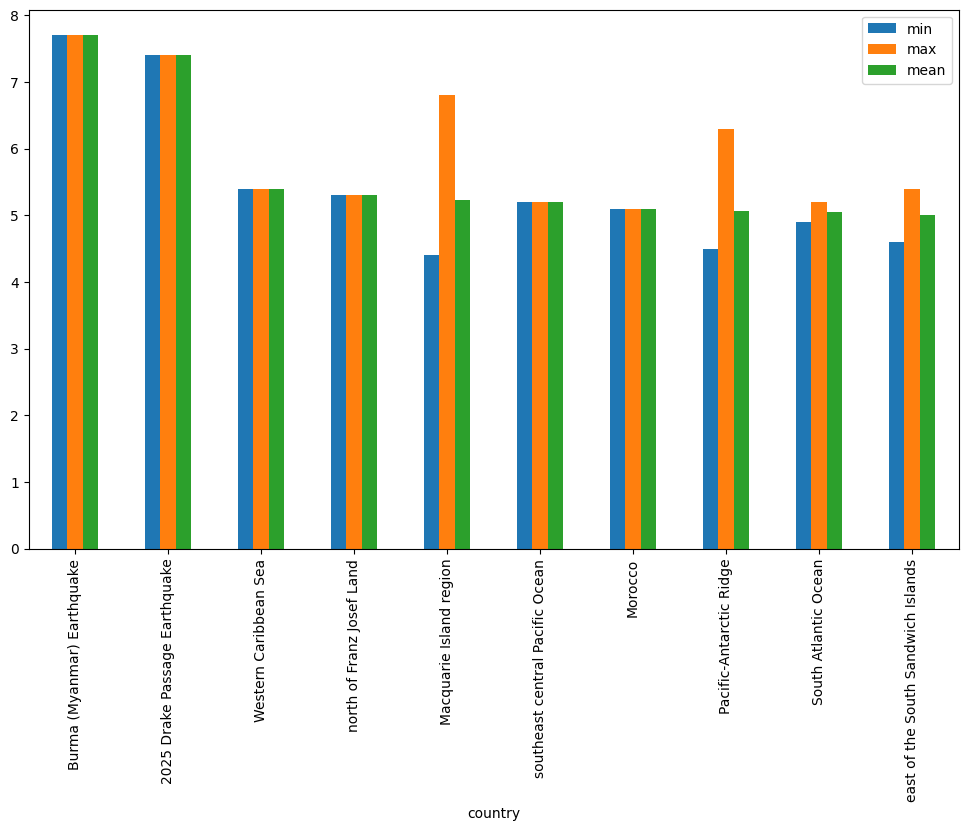

In [30]:
gb.mag.aggregate(['min', 'max', 'mean']).nlargest(10, 'mean').plot(kind='bar')

:::{admonition} Try it
:class: tip
Group the earthquakes by country and use `.aggregate(['min', 'max', 'mean'])` on the `mag` column to get all three statistics at once. Then sort by the mean magnitude in descending order and grab the top 10 countries.
:::

In [31]:
# Try it — my attempt
agg = df.groupby('country').mag.aggregate(['min', 'max', 'mean'])
agg.sort_values('mean', ascending=False).head(10)

,min,max,mean
country,,,
Burma (Myanmar) Earthquake,7.7,7.7,7.700000
2025 Drake Passage Earthquake,7.4,7.4,7.400000
Western Caribbean Sea,5.4,5.4,5.400000
north of Franz Josef Land,5.3,5.3,5.300000
Macquarie Island region,4.4,6.8,5.233333
southeast central Pacific Ocean,5.2,5.2,5.200000
Morocco,5.1,5.1,5.100000
Pacific-Antarctic Ridge,4.5,6.3,5.070588
South Atlantic Ocean,4.9,5.2,5.050000


## Transformation

The key difference between aggregation and transformation is that aggregation returns a *smaller* object than the original, indexed by the group keys, while *transformation* returns an object with the same index (and same size) as the original object. Groupby + transformation is used when applying an operation that requires information about the whole group.

In this example, we standardize the earthquakes in each country so that the distribution has zero mean and unit variance. We do this by first defining a function called `standardize` and then passing it to the `transform` method.

I admit that I don't know why you would want to do this. `transform` makes more sense to me in the context of time grouping operation. See below for another example.

In [32]:
def standardize(x):
    return (x - x.mean())/x.std()

mag_standardized_by_country = gb.mag.transform(standardize)
mag_standardized_by_country.head()

,mag
id,
us6000qkt1,0.668464
us6000qksf,0.419407
us6000qks2,2.157996
us6000qkrz,0.642692
us6000qks0,0.909743


:::{admonition} Try it
:class: tip
Define a function `standardize(x)` that returns `(x - x.mean()) / x.std()`. Use it with `df.groupby('country').mag.transform(standardize)` and plot a histogram of the result — magnitudes should now be approximately centered on zero within each country.
:::

<Axes: title={'center': 'Magnitudes standardized within each country'}, ylabel='Frequency'>

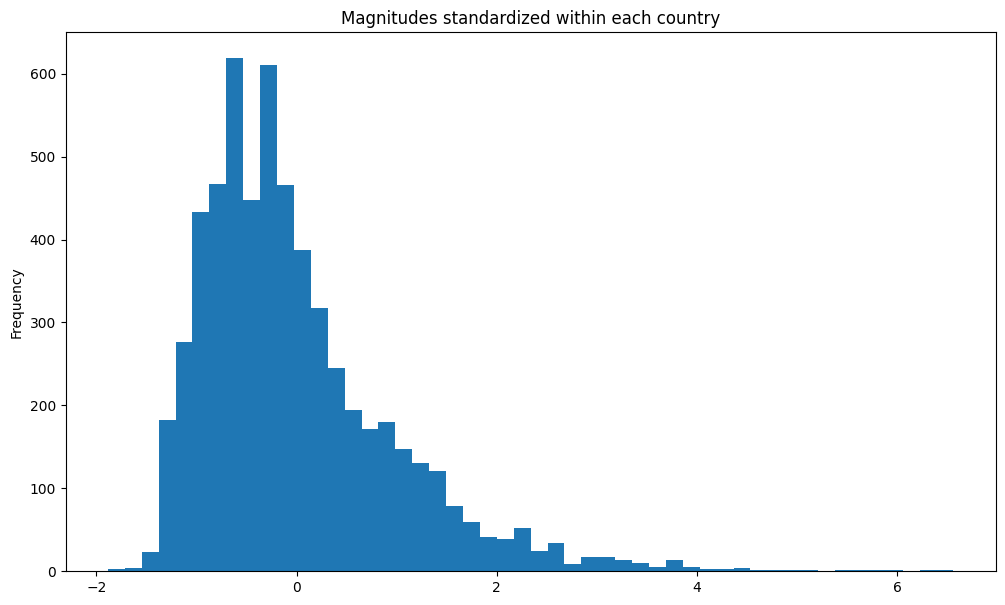

In [33]:
# Try it — my attempt
def standardize(x):
    return (x - x.mean()) / x.std()
mag_std = df.groupby('country').mag.transform(standardize)
mag_std.plot.hist(bins=50, title='Magnitudes standardized within each country')

## Time Grouping

We already saw how pandas has a strong built-in understanding of time. This capability is even more powerful in the context of `groupby`. With datasets indexed by a pandas `DateTimeIndex`, we can easily group and resample the data using common time units.

To get started, let's load the timeseries data we already explored in past lessons.

In [34]:
import pooch
import pandas as pd

POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
    },
)

with open(POOCH.fetch("HEADERS.txt")) as fp:
    headers = fp.read().split("\n")[1].split(" ")

dframes = []
for year in range(2016, 2019):
    fname = f"CRND0103-{year}-NY_Millbrook_3_W.txt"
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep=r"\s+",
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index("LST_DATE")
df.head()

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY,
LST_DATE,,,,,,,,,,,,,,,,,,,,,
2016-01-01,64756,2.422,-73.74,41.79,3.4,-0.5,1.5,1.3,0.0,1.69,...,0.233,0.204,0.155,0.147,4.2,4.4,5.1,6.0,7.6,NaN
2016-01-02,64756,2.422,-73.74,41.79,2.9,-3.6,-0.4,-0.3,0.0,6.25,...,0.227,0.199,0.152,0.144,2.8,3.1,4.2,5.7,7.4,NaN
2016-01-03,64756,2.422,-73.74,41.79,5.1,-1.8,1.6,1.1,0.0,5.69,...,0.223,0.196,0.151,0.141,2.6,2.8,3.8,5.2,7.2,NaN
2016-01-04,64756,2.422,-73.74,41.79,0.5,-14.4,-6.9,-7.5,0.0,9.17,...,0.220,0.194,0.148,0.139,1.7,2.1,3.4,4.9,6.9,NaN
2016-01-05,64756,2.422,-73.74,41.79,-5.2,-15.5,-10.3,-11.7,0.0,9.34,...,0.213,0.191,0.148,0.138,0.4,0.9,2.4,4.3,6.6,NaN


This timeseries has daily resolution, and the daily plots are somewhat noisy.

<Axes: xlabel='LST_DATE'>

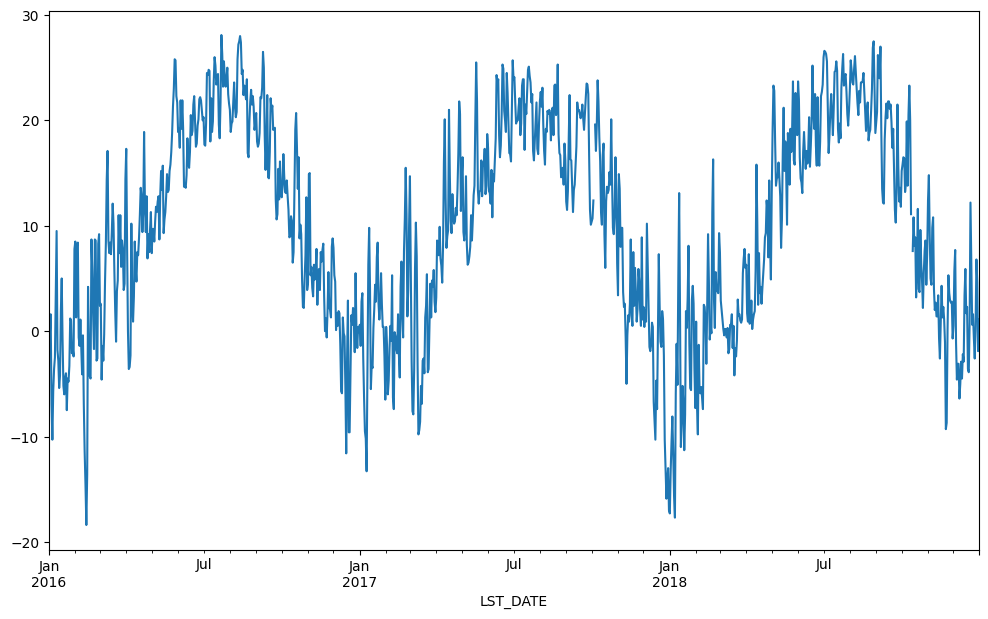

In [35]:
df.T_DAILY_MEAN.plot()

A common way to analyze such data in climate science is to create a "climatology," which contains the average values in each month or day of the year. We can do this easily with groupby. Recall that `df.index` is a pandas `DateTimeIndex` object.

In [36]:
df.index

DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04',
               '2016-01-05', '2016-01-06', '2016-01-07', '2016-01-08',
               '2016-01-09', '2016-01-10',
               ...
               '2018-12-22', '2018-12-23', '2018-12-24', '2018-12-25',
               '2018-12-26', '2018-12-27', '2018-12-28', '2018-12-29',
               '2018-12-30', '2018-12-31'],
              dtype='datetime64[ns]', name='LST_DATE', length=1096, freq=None)

In [37]:
df.index.month

Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       ...
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12],
      dtype='int32', name='LST_DATE', length=1096)

In [38]:
monthly_climatology = df.select_dtypes(include='number').groupby(df.index.month).mean()
monthly_climatology

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY,
LST_DATE,,,,,,,,,,,,,,,,,,,,,
1,64756.0,2.488667,-73.74,41.79,2.924731,-7.122581,-2.100000,-1.905376,2.478495,5.812258,...,0.240250,0.200717,0.153667,0.160880,0.150538,0.248387,0.788172,1.766667,3.364516,NaN
2,64756.0,2.487882,-73.74,41.79,6.431765,-5.015294,0.712941,1.022353,4.077647,8.495882,...,0.247771,0.210067,0.159176,0.163901,1.216471,1.169412,1.278824,1.617647,2.442353,NaN
3,64756.0,2.488667,-73.74,41.79,7.953763,-3.035484,2.455914,2.643011,2.788172,13.211290,...,0.228624,0.203634,0.157817,0.160366,3.450538,3.400000,3.372043,3.480645,3.777419,NaN
4,64756.0,2.488667,-73.74,41.79,14.793333,1.816667,8.302222,8.574444,2.396667,15.295889,...,0.214078,0.195844,0.153922,0.158100,9.415556,9.117778,8.455556,7.618889,6.670000,NaN
5,64756.0,2.488667,-73.74,41.79,21.235484,8.460215,14.850538,15.121505,3.015054,17.288602,...,0.204796,0.187097,0.148892,0.155720,16.934409,16.640860,15.612903,14.208602,12.455914,NaN
6,64756.0,2.488667,-73.74,41.79,25.627778,11.837778,18.733333,19.026667,3.053333,21.913333,...,0.136933,0.135211,0.129422,0.152722,22.403333,22.126667,20.956667,19.448889,17.552222,NaN
7,64756.0,2.488667,-73.74,41.79,28.568817,15.536559,22.054839,22.012903,3.865591,21.570645,...,0.105817,0.095204,0.114430,0.150014,25.448387,25.318280,24.163441,22.746237,21.068817,NaN
8,64756.0,2.488667,-73.74,41.79,27.473118,15.351613,21.410753,21.378495,4.480645,18.493333,...,0.156161,0.132333,0.128839,0.158800,24.758065,24.829032,24.116129,23.325806,22.301075,NaN
9,64756.0,2.488667,-73.74,41.79,24.084444,12.032222,18.057778,17.866667,3.730000,13.625667,...,0.136911,0.126456,0.121378,0.154000,21.028889,21.168889,20.921111,20.834444,20.707778,NaN


<Axes: xlabel='LST_DATE'>

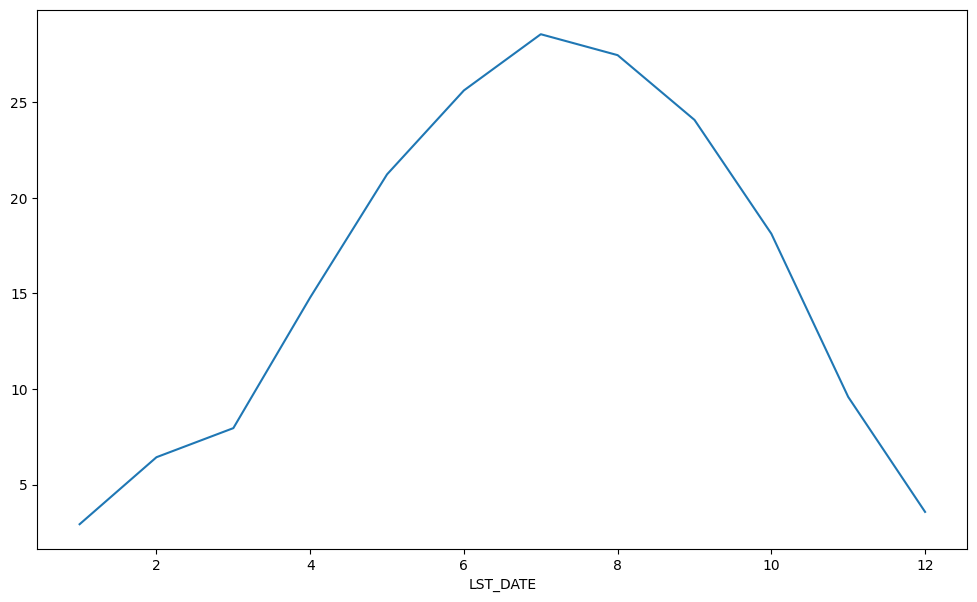

In [39]:
monthly_climatology.T_DAILY_MAX.plot()

Each row in this new dataframe represents the average values for the months (1=January, 2=February, etc.)

We can apply more customized aggregations, as with any groupby operation. Below we keep the mean of the mean, max of the max, and min of the min for the temperature measurements.

In [40]:
monthly_T_climatology = df.groupby(df.index.month).aggregate({'T_DAILY_MEAN': 'mean',
                                                              'T_DAILY_MAX': 'max',
                                                              'T_DAILY_MIN': 'min'})
monthly_T_climatology

,T_DAILY_MEAN,T_DAILY_MAX,T_DAILY_MIN
LST_DATE,,,
1,-2.100000,16.9,-26.0
2,0.712941,24.9,-24.7
3,2.455914,26.8,-16.5
4,8.302222,30.6,-11.3
5,14.850538,33.4,-1.6
6,18.733333,33.8,3.4
7,22.054839,35.7,8.2
8,21.410753,34.5,6.0
9,18.057778,32.7,0.3


<Axes: xlabel='LST_DATE'>

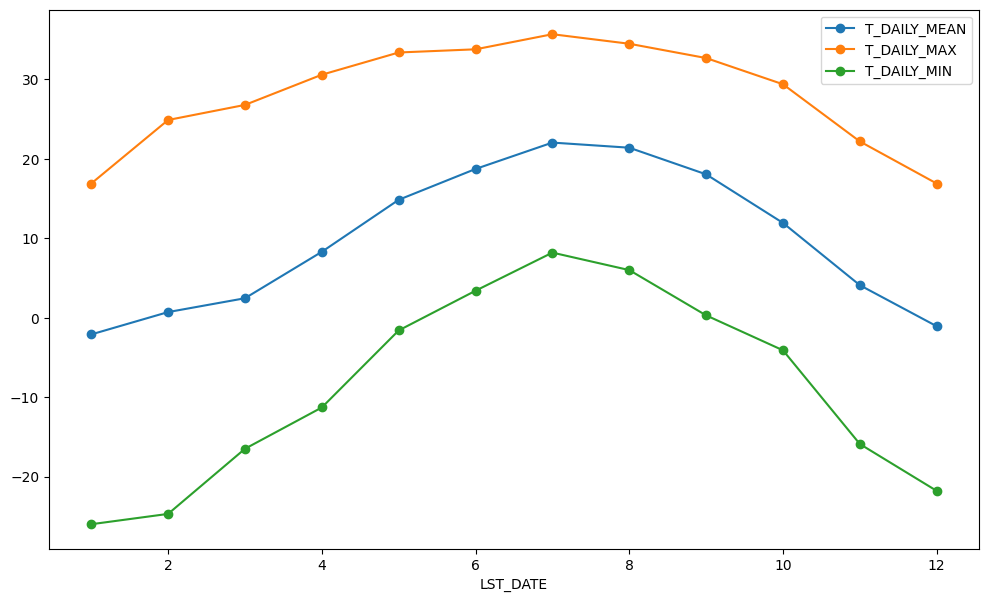

In [41]:
monthly_T_climatology.plot(marker='o')

If we want to do it on a finer scale, we can group by day of year.

<Axes: xlabel='LST_DATE'>

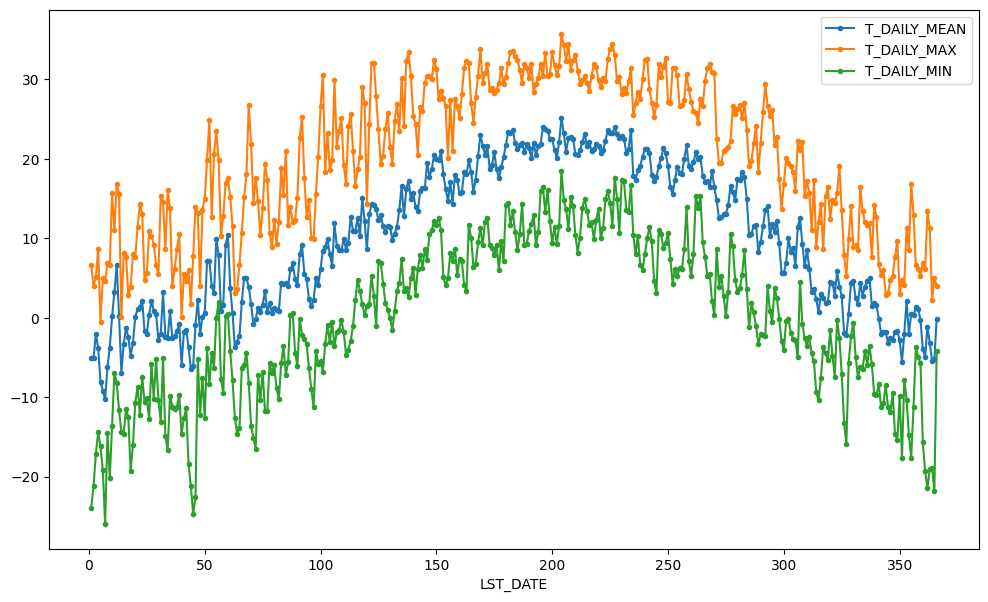

In [42]:
daily_T_climatology = df.groupby(df.index.dayofyear).aggregate({'T_DAILY_MEAN': 'mean',
                                                            'T_DAILY_MAX': 'max',
                                                            'T_DAILY_MIN': 'min'})
daily_T_climatology.plot(marker='.')

### Calculating anomalies

A common mode of analysis in climate science is to remove the climatology from a signal to focus only on the "anomaly" values. This can be accomplished with transformation.

In [43]:
def remove_climatology(x):
    return x - x.mean()

anomaly = df.groupby(df.index.month).T_DAILY_MEAN.transform(remove_climatology)
anomaly

,T_DAILY_MEAN
LST_DATE,
2016-01-01,3.600000
2016-01-02,1.700000
2016-01-03,3.700000
2016-01-04,-4.800000
2016-01-05,-8.200000
...,...
2018-12-27,1.269892
2018-12-28,7.869892
2018-12-29,5.669892


<Axes: xlabel='LST_DATE'>

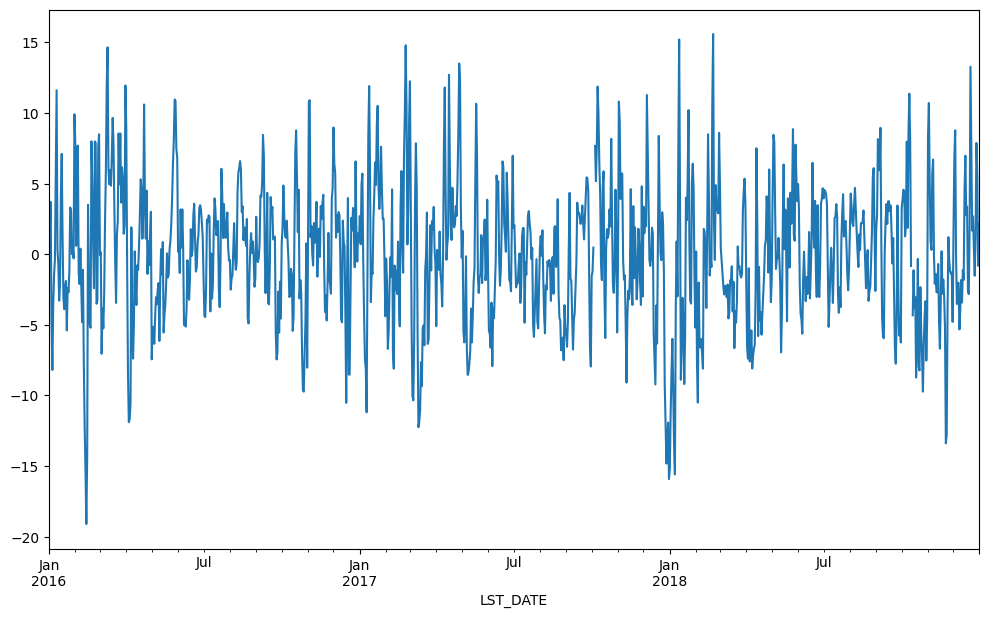

In [44]:
anomaly.plot()

:::{admonition} Try it
:class: tip
Compute a **daily** climatology of `T_DAILY_MEAN` by grouping on `df.index.dayofyear` and taking the mean. Plot it as a line chart. Compare its shape to the monthly climatology shown above — the daily curve will be noisier but pick up sub-monthly structure.
:::

<Axes: title={'center': 'Daily climatology of T_DAILY_MEAN'}, xlabel='LST_DATE'>

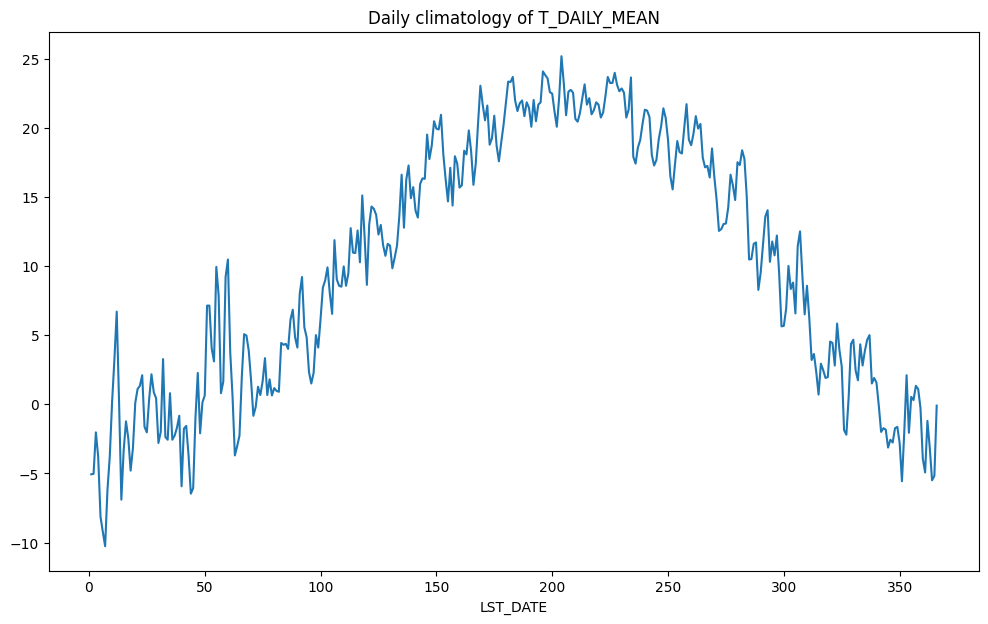

In [45]:
# Try it — my attempt  (uses the NOAA station df loaded above)
daily_clim = df.groupby(df.index.dayofyear).T_DAILY_MEAN.mean()
daily_clim.plot(title='Daily climatology of T_DAILY_MEAN')

### Resampling

We met `resample` at the end of the previous notebook (*Pandas Fundamentals*) as a way to change a time series' resolution. Now that we understand `groupby`, we can name what `resample` actually is: **a `groupby` over time bins**. Instead of grouping rows by the value in a column, it groups them by which time interval they fall into — each month, each year, and so on — then applies an aggregation. It's the same split-apply-combine idea, just with time as the grouping key.

The bin size is given using pandas [offset-alias](http://pandas.pydata.org/pandas-docs/stable/timeseries.html#offset-aliases) syntax (e.g. `'ME'` = month end, `'YE'` = year end). Below we resample to a monthly frequency, taking the mean over each month.

<Axes: xlabel='LST_DATE'>

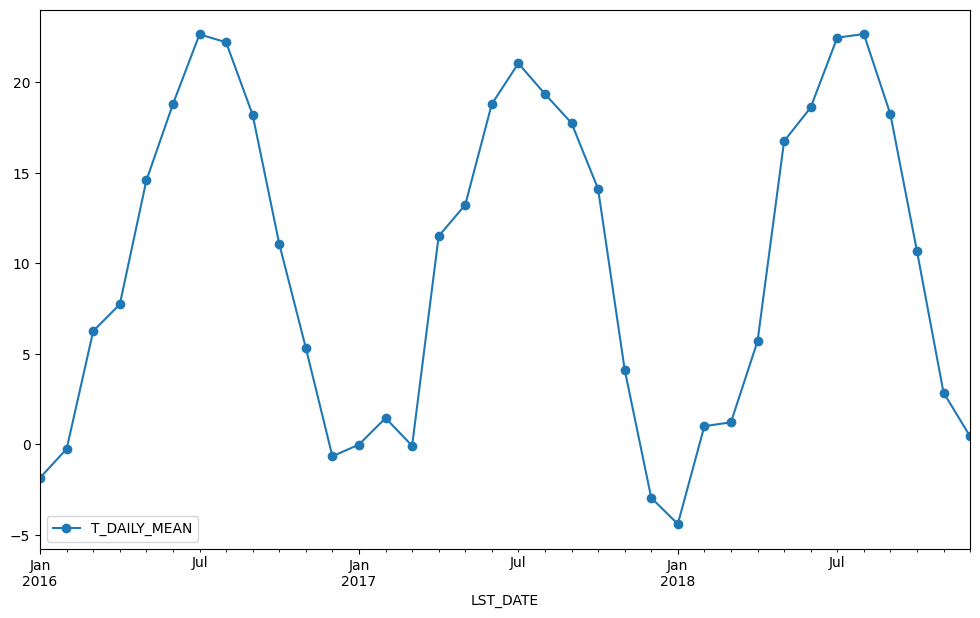

In [46]:
df.select_dtypes(include='number').resample('ME').mean().plot(y='T_DAILY_MEAN', marker='o')

<Axes: xlabel='LST_DATE'>

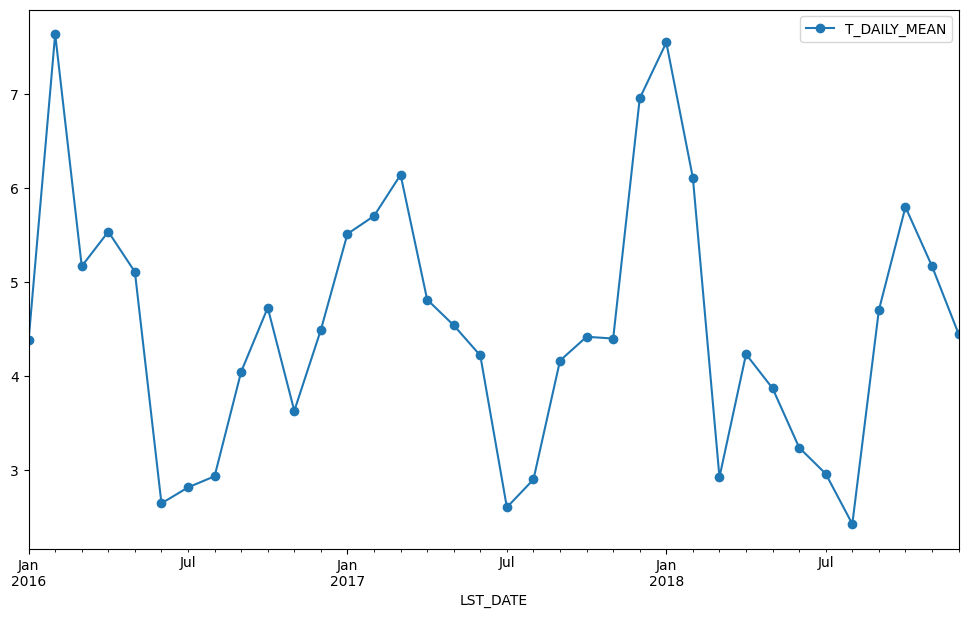

In [47]:
df.select_dtypes(include='number').resample('ME').std().plot(y='T_DAILY_MEAN', marker='o')

Just like with `groupby`, we can apply any aggregation function to our `resample` operation.

<Axes: xlabel='LST_DATE'>

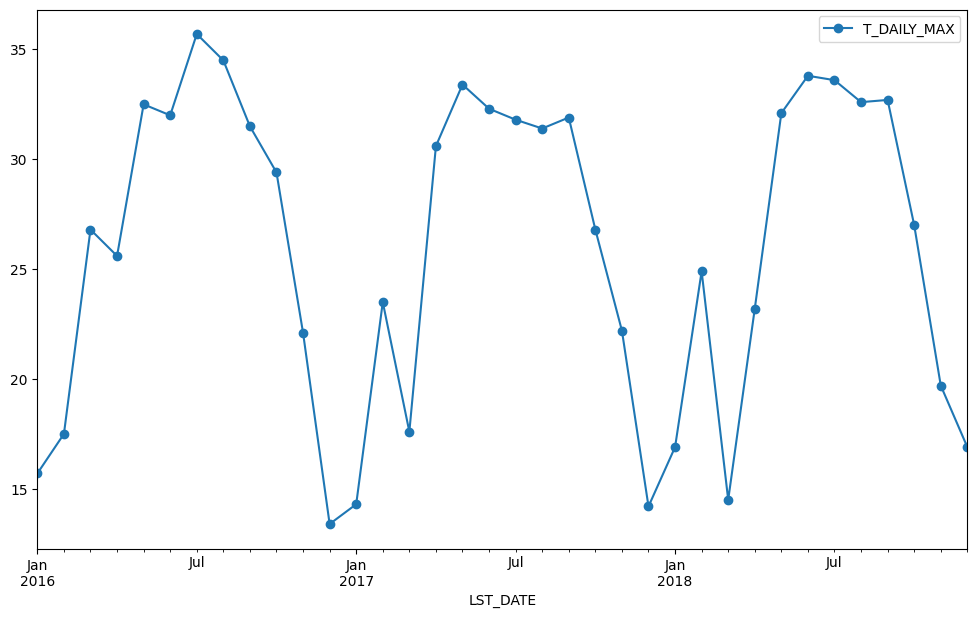

In [48]:
df.select_dtypes(include='number').resample('ME').max().plot(y='T_DAILY_MAX', marker='o')

:::{admonition} Try it
:class: tip
Use `df.resample('YE').max()` to get the yearly maximum and plot `T_DAILY_MAX` against the resulting yearly index. Compare with the monthly resampling shown above — what trend, if any, do you see?
:::

<Axes: title={'center': 'Yearly maximum of T_DAILY_MAX'}, xlabel='LST_DATE'>

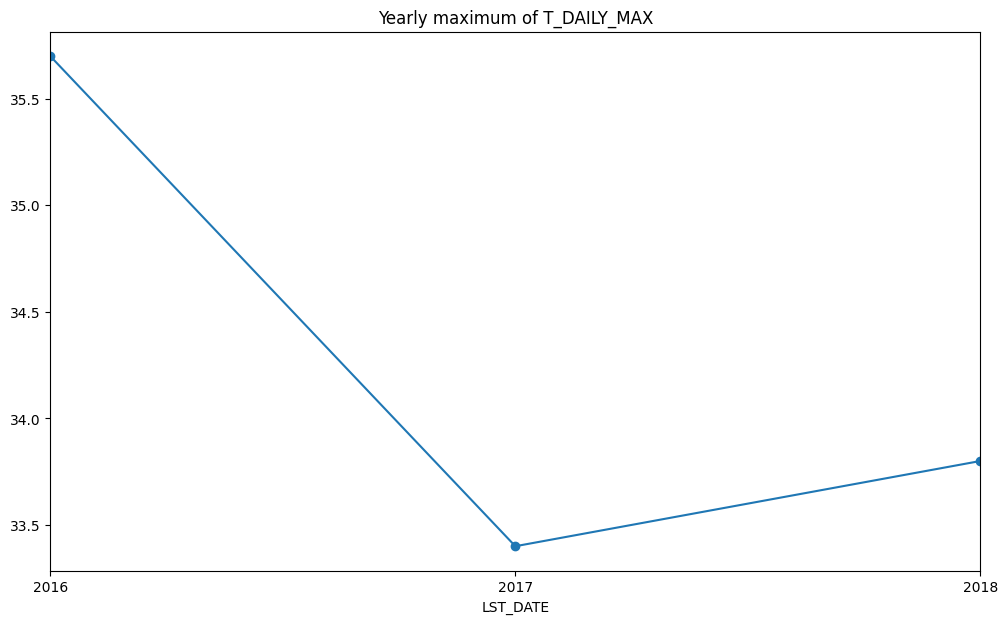

In [49]:
# Try it — my attempt
df.select_dtypes('number').resample('YE').max()['T_DAILY_MAX'].plot(marker='o',
    title='Yearly maximum of T_DAILY_MAX')

### Rolling Operations

The final category of operations applies to "rolling windows". (See [rolling](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.rolling.html) documentation.) We specify a function to apply over a moving window along the index. We specify the size of the window and, optionally, the weights. We also use the keyword `center` to tell pandas whether to center the operation around the midpoint of the window.

<Axes: xlabel='LST_DATE'>

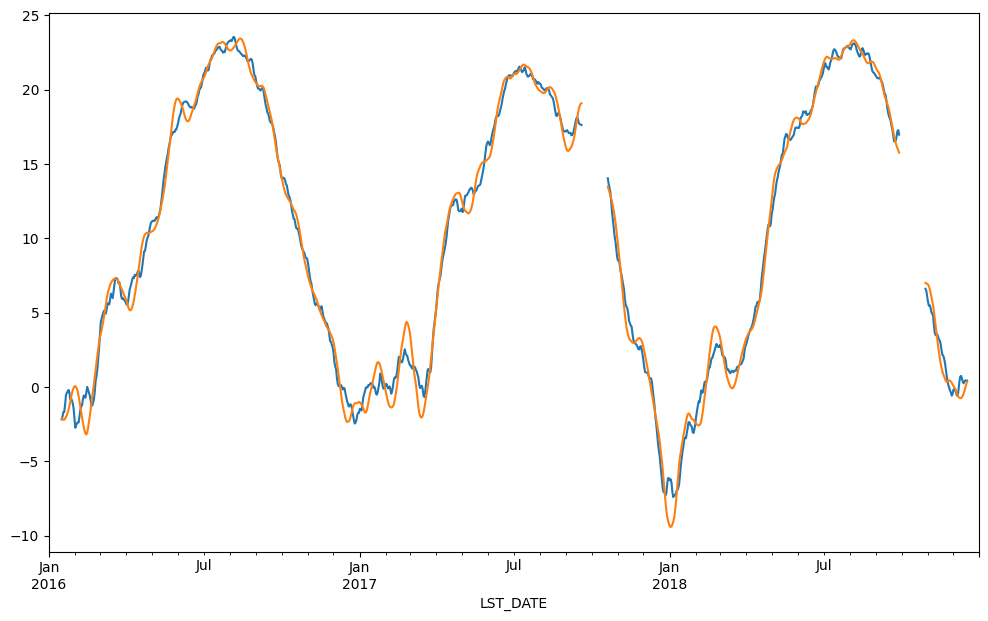

In [50]:
df.rolling(30, center=True).T_DAILY_MEAN.mean().plot()
df.rolling(30, center=True, win_type='triang').T_DAILY_MEAN.mean().plot()

<Axes: xlabel='LST_DATE'>

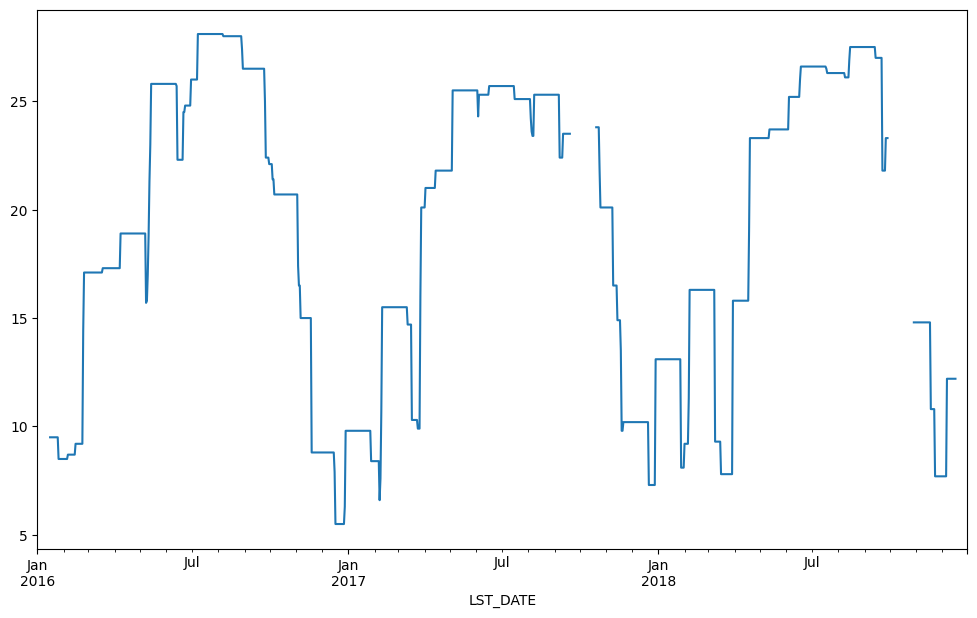

In [51]:
df.rolling(30, center=True).T_DAILY_MEAN.max().plot()


:::{admonition} Try it
:class: tip
Use `df.rolling(7, center=True).T_DAILY_MEAN.mean()` to compute a 7-day moving average and plot it. Then overlay the raw daily series on the same axes (call `.plot()` twice on the same axes, or use `fig, ax = plt.subplots()` and call `.plot(ax=ax)` for each). What does smoothing reveal that the raw data hides?
:::

Text(0.5, 1.0, '7-day moving average vs raw daily')

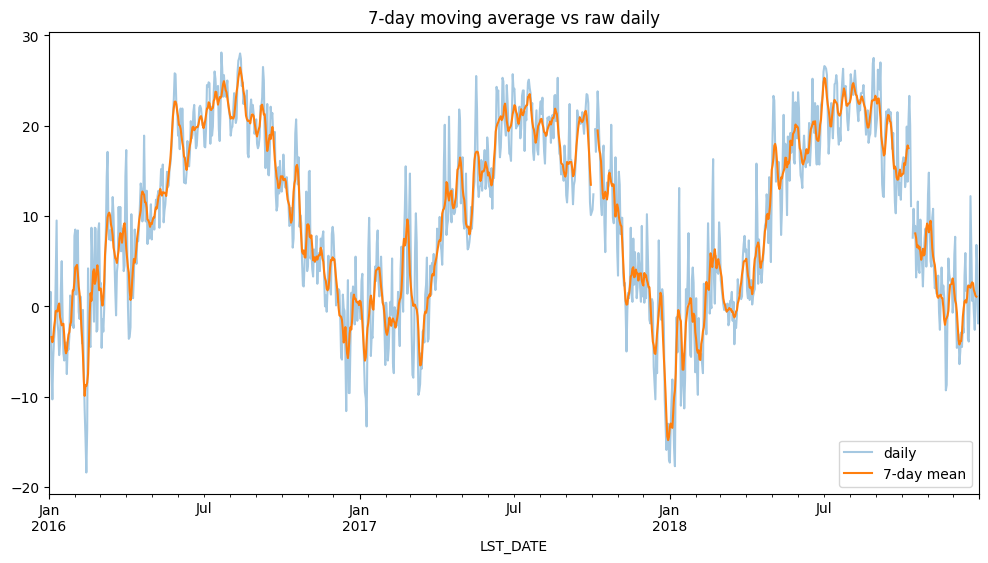

In [52]:
# Try it — my attempt
fig, ax = plt.subplots(figsize=(12, 6))
df.T_DAILY_MEAN.plot(ax=ax, alpha=0.4, label='daily')
df.rolling(7, center=True).T_DAILY_MEAN.mean().plot(ax=ax, label='7-day mean')
ax.legend(); ax.set_title('7-day moving average vs raw daily')

## Recap

This notebook was all about **split–apply–combine**:

- **`groupby` on a column** — grouping earthquakes by country, then summarizing each group with **aggregation** (`count`, `mean`, `.aggregate([...])`).
- **Transformation** — returning a value for every row using whole-group information (standardizing within each group; removing a climatology to get anomalies).
- **Time grouping** — grouping by parts of a `DatetimeIndex` to build a **climatology**.
- **`resample`** — a `groupby` over time bins, for changing time resolution.
- **`rolling`** — moving-window calculations for smoothing.

These same `groupby` / `resample` / `rolling` ideas carry straight into the next section, **Xarray**, where they work on labelled N-dimensional arrays.